# BESS Layout Optimization Tool

This notebook implements a layout optimization engine for Battery Energy Storage Systems (BESS).

## Objectives

- Define an arbitrary site using a polygon
- Place different types of equipment:
  - BESS containers (20 ft)
  - MVS / PCS containers (20 ft)
- Define:
  - Equipment footprint (2D)
  - Clearance distances (overlapping allowed)
- Configure maximum number of BESS per MVS
- Optimize layout to maximize battery count under constraints

## Key Assumptions

- Rectangular equipment footprints
- Clearance zones are allowed to overlap
- Equipment footprints cannot overlap
- Each BESS must be assigned to a MVS

In [14]:
# Install required packages (run once)

!pip install shapely matplotlib numpy


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Environment Check

This section ensures that all required libraries are correctly installed.

If this cell runs successfully, the environment is ready to execute the layout optimization workflow.

In [15]:
# Quick sanity check

from shapely.geometry import Polygon

poly = Polygon([(0, 0), (10, 0), (10, 10), (0, 10)])

print("✅ Shapely working correctly:", poly.area == 100)

✅ Shapely working correctly: True


# Configuration

In this section, the main parameters of the layout problem are defined.

## Site Definition
- The site is defined as a polygon using a list of vertices (X, Y)

## Zone Types

Two types of zones are defined:

### 1. Non-buildable areas
- Equipment cannot be placed
- Can still be used for:
  - cable routing
  - access paths
  - fire lanes
- These areas block placement but do not reduce total usable layout space

### 2. Restricted areas
- Completely excluded from the site
- No usage allowed
- These areas are subtracted from the site geometry

## Equipment Types
- BESS containers
- MVS / PCS containers

Each equipment type includes:
- Footprint (width and height)
- Clearance (allowed to overlap with other clearance zones)

## System Constraints
- Maximum number of BESS units per MVS
- Grid resolution for placement candidates

This structure allows modeling realistic BESS layouts with engineering constraints.

In [16]:
# =========================================================
# ZONE DEFINITIONS
# =========================================================
# Trace the image measurements:
#
#   TOTAL SITE: 53.3 m wide × 90.4 m tall
#
#   Cable corridor (diagonal, non-buildable):
#     bottom: x = [15.4, 21.9]  →  6.5 m wide
#     top:    x = [31.9, 47.7]  →  15.8 m wide
#
#   Lower-right triangle: base 31.4 m, height ~16 m  (244 m²)
#
#   Top-left indent: 8 m step at the upper-left corner
# =========================================================

# Cable protection corridor — diagonal, widens top to bottom
cable_corridor = [
    (15.4,  0),
    (21.9,  0),
    (47.7,  90.4),
    (31.9,  90.4)
]

# Area outside scope (solar panels) — right of cable corridor above y = 16 m
# Defined as RESTRICTED: completely removed from site geometry
out_of_scope = [
    (21.9,  16),
    (53.3,  16),
    (53.3,  90.4),
    (47.7,  90.4)
]


In [17]:
# =========================================================
# KEY INPUTS — edit here before running
# =========================================================

# --- Equipment footprint dimensions (metres) ---
# Sungrow PowerTitan 20-ft container
BESS_WIDTH  = 6.06
BESS_HEIGHT = 2.44

MVS_WIDTH   = 6.06
MVS_HEIGHT  = 2.44

# --- Clearance distances (metres) — asymmetric per side ---
#   front = facing the access aisle (+ Y direction)
#   back  = rear of the container   (- Y direction)
#   left  = left side               (- X direction)
#   right = right side              (+ X direction)
#
# Clearances are shown in the plot but NOT hard exclusions:
# clearance zones CAN overlap with each other — only footprints cannot.
# Footprints also cannot enter another container's clearance zone.

BESS_CLEARANCE = {
    "front": 2.0,
    "back":  1.0,
    "left":  1.0,
    "right": 1.0,
}

MVS_CLEARANCE = {
    "front": 3.0,
    "back":  1.5,
    "left":  1.5,
    "right": 1.5,
}

# --- System constraints ---
MAX_BESS_PER_MVS = 4

# Additional minimum centre-to-centre distance between MVS units (m).
# Set to 0 to rely only on the clearance geometry (recommended).
# Set to e.g. 12.0 only if an engineering/access requirement demands it —
# note that larger values drastically reduce total BESS count.
MIN_MVS_SPACING  = 0

# --- Layout resolution ---
# Use a step close to the BESS width for better row alignment.
GRID_RESOLUTION = 2.0

SETBACK = 0

# --- Cable crossing strategy ---
#
#   False → Greedy per-cluster: each MVS is filled with its closest BESS
#            before moving to the next.  Maximises BESS count.
#            Cables from different clusters may cross.
#
#   True  → Voronoi: each BESS goes to the geometrically nearest MVS.
#            Prevents cable crossings; may place fewer BESS.
#
AVOID_CABLE_CROSSINGS = False


In [18]:
# =========================================================
# CONFIGURATION  (references KEY INPUTS above)
# =========================================================

CONFIG = {

    # ---------------------------
    # SITE DEFINITION
    # ---------------------------
    # Vertices traced from the image (clockwise from bottom-left):
    #
    #   (0, 0)        bottom-left
    #   (53.3, 0)     bottom-right  (15.4 + 6.5 + 31.4 = 53.3 m)
    #   (53.3, 16)    right side of lower triangle (height ~16 m)
    #   (21.9, 16)    triangle apex — site cuts back left here
    #   (47.7, 90.4)  top-right (cable corridor right edge at top)
    #   (8,    90.4)  top-left with 8 m indent
    #   (0,    90.4)  top-left corner
    #
    # The cable corridor (non-buildable) runs diagonally inside this polygon.
    # The solar-panel area above y=16 and right of the corridor is removed via
    # the restricted zone.
    "site_vertices": [
        (0,     0),
        (53.3,  0),
        (53.3,  16),    # top-right of lower triangle
        (21.9,  16),    # triangle apex
        (47.7,  90.4),  # follows cable corridor right edge to top
        (8,     90.4),  # top-left with 8 m indent
        (0,     90.4),  # top-left corner
    ],

    "setback": SETBACK,

    # ---------------------------
    # ZONES
    # ---------------------------
    "zones": {
        "non_buildable": [cable_corridor],
        "restricted":    [out_of_scope]
    },

    # ---------------------------
    # EQUIPMENT TYPES
    # ---------------------------
    "equipment": {
        "BESS": {
            "width":     BESS_WIDTH,
            "height":    BESS_HEIGHT,
            "clearance": BESS_CLEARANCE
        },
        "MVS": {
            "width":     MVS_WIDTH,
            "height":    MVS_HEIGHT,
            "clearance": MVS_CLEARANCE
        }
    },

    # ---------------------------
    # SYSTEM CONSTRAINTS
    # ---------------------------
    "max_bess_per_mvs":      MAX_BESS_PER_MVS,
    "min_mvs_spacing":       MIN_MVS_SPACING,
    "grid_resolution":       GRID_RESOLUTION,
    "avoid_cable_crossings": AVOID_CABLE_CROSSINGS,
}


# Geometry and Site Preparation

This section defines how the site geometry is prepared before placing equipment.

## Key Steps

1. Create the base site polygon from vertices
2. Apply setback (inward buffer)
3. Subtract restricted areas from the site
4. Keep non-buildable zones as internal constraints
5. Generate candidate placement positions using a grid

## Important Behavior

- Restricted areas → removed from the usable site
- Non-buildable areas → remain inside the site but block placement
- Clearance between equipment is allowed to overlap

The combination of these rules allows realistic modeling of:
- access roads
- fire lanes
- no-build zones
- environmental restrictions

In [19]:
from shapely.geometry import Polygon
import numpy as np

def create_site(vertices):
    site = Polygon(vertices)

    if not site.is_valid:
        raise ValueError("Invalid polygon: check vertex order")

    return site


def prepare_site(site, config):

    # 1. Apply setback
    usable_site = site.buffer(-config["setback"])

    # 2. Remove restricted zones
    for zone in config["zones"]["restricted"]:
        zone_poly = Polygon(zone)
        usable_site = usable_site.difference(zone_poly)

    # 3. Keep non-buildable zones (for placement checks later)
    non_buildable_polys = [
        Polygon(z) for z in config["zones"]["non_buildable"]
    ]

    return usable_site, non_buildable_polys


def create_candidate_grid(site, resolution):
    minx, miny, maxx, maxy = site.bounds

    xs = np.arange(minx, maxx, resolution)
    ys = np.arange(miny, maxy, resolution)

    return [(x, y) for x in xs for y in ys]

# Equipment Placement Logic

This section defines how equipment is placed within the site.

## Placement Rules

### 1. Footprint constraints
- Equipment footprints must:
  - Be fully inside the usable site
  - Not intersect with other equipment
  - Not overlap with non-buildable zones

### 2. Clearance concept
- Each equipment has a clearance distance
- Clearance areas:
  - Can overlap with other clearances
  - Represent safety, fire, or O&M spacing
- Clearance is NOT treated as a hard exclusion

### 3. Placement Strategy

The placement is done sequentially:

1. Place MVS units first
2. Assign BESS units to MVS based on proximity
3. Ensure each MVS does not exceed maximum BESS capacity

## Objective

Maximize the number of BESS units while ensuring:
- Proper assignment to MVS
- Valid spatial layout


In [20]:
from shapely.geometry import box

def create_equipment_polygon(x, y, width, height):
    return box(x, y, x + width, y + height)


def create_clearance_polygon(footprint, clearance):
    """
    Build an asymmetric clearance rectangle around a footprint.
    clearance dict keys: front (+Y), back (-Y), left (-X), right (+X).
    """
    minx, miny, maxx, maxy = footprint.bounds
    return box(
        minx - clearance["left"],
        miny - clearance["back"],
        maxx + clearance["right"],
        maxy + clearance["front"],
    )


def is_valid_placement(candidate_fp, candidate_cl, site, non_buildable, placed):
    """
    Placement rules:
      - Footprint must be fully inside the usable site
      - Footprint must not intersect non-buildable zones
      - Footprint must not enter any existing clearance zone
      - New clearance zone must not overlap any existing footprint
      (clearance zones CAN overlap each other — that is allowed)
    """
    if not site.contains(candidate_fp):
        return False

    for zone in non_buildable:
        if candidate_fp.intersects(zone):
            return False

    for obj in placed:
        # New footprint inside existing clearance zone → blocked
        if candidate_fp.intersects(obj["clearance_zone"]):
            return False
        # New clearance zone overlaps existing footprint → blocked
        if candidate_cl.intersects(obj["footprint"]):
            return False

    return True


# MVS and BESS Placement Strategy

This section defines the logic used to allocate equipment across the site.

## MVS Placement

- MVS units are placed first
- They act as anchors for BESS allocation
- Placement is based on valid grid positions

## BESS Placement

- BESS units are placed after MVS
- Each BESS unit is assigned to the nearest MVS
- Assignment is constrained by:
  - Maximum BESS per MVS

## Optimization Philosophy

- Prioritize filling MVS to maximum capacity
- Use proximity (distance) as assignment metric
- Avoid scattered layouts where possible

This approach approximates real BESS design methodology where:
- Power blocks are centered around PCS/MVS
- Batteries are clustered around conversion units

In [21]:
def place_clusters(site, non_buildable, grid, config):
    """
    Interleaved cluster placement: one MVS + its BESS at a time.

    avail tracks ALL positions free of placed equipment (MVS and BESS).

    Each iteration:
      1. Score every valid MVS candidate by the sum of distances to its
         max_bess_per_mvs nearest positions in avail (cable-length proxy).
      2. Commit the best MVS; prune avail for its clearance zone.
      3. Immediately fill that MVS with up to max_bess_per_mvs BESS using
         a dynamic compactness score: dist_to_MVS + 0.5 * dist_to_nearest_cluster_member.
         This pulls each successive BESS toward the growing cluster,
         creating tighter row-like shapes instead of scattered arrangements.
      4. Repeat until avail is too sparse to score another MVS.

    avoid_cable_crossings = True adds a Voronoi swap pass at the end:
      All BESS keep their physical positions but are globally reassigned to
      the nearest MVS with remaining capacity, eliminating cable crossings.
    """
    mvs_eq          = config["equipment"]["MVS"]
    bess_eq         = config["equipment"]["BESS"]
    mvs_cl_dict     = mvs_eq["clearance"]
    bess_cl_dict    = bess_eq["clearance"]
    min_spacing     = config.get("min_mvs_spacing", 0)
    max_ratio       = config["max_bess_per_mvs"]
    avoid_crossings = config.get("avoid_cable_crossings", False)

    cx_off = bess_eq["width"]  / 2
    cy_off = bess_eq["height"] / 2

    placed    = []
    mvs_list  = []
    bess_list = []

    # avail = positions not yet blocked by any placed equipment
    avail = list(grid)

    while True:
        # Need self + max_ratio neighbours to compute a meaningful score
        if len(avail) < max_ratio + 1:
            break

        avail_arr = np.array([[x + cx_off, y + cy_off] for x, y in avail])

        best_pos   = None
        best_score = float("inf")
        best_fp    = None
        best_cl    = None

        for (mx, my) in avail:
            mvs_fp = create_equipment_polygon(mx, my, mvs_eq["width"], mvs_eq["height"])
            mvs_cl = create_clearance_polygon(mvs_fp, mvs_cl_dict)

            if not is_valid_placement(mvs_fp, mvs_cl, site, non_buildable, placed):
                continue

            cx, cy = mvs_fp.centroid.x, mvs_fp.centroid.y
            if min_spacing > 0 and any(
                (cx - m["footprint"].centroid.x) ** 2 + (cy - m["footprint"].centroid.y) ** 2
                < min_spacing ** 2
                for m in mvs_list
            ):
                continue

            dists = np.hypot(avail_arr[:, 0] - cx, avail_arr[:, 1] - cy)
            top_k = np.sort(dists)[1 : max_ratio + 1]
            if top_k.size == 0:
                continue
            score = float(top_k.sum())
            if score < best_score:
                best_score, best_pos, best_fp, best_cl = score, (mx, my), mvs_fp, mvs_cl

        if best_pos is None:
            break

        # ── Place MVS ────────────────────────────────────────────────────
        mvs_obj = {
            "type":           "MVS",
            "footprint":      best_fp,
            "clearance_zone": best_cl,
            "assigned_bess":  []
        }
        placed.append(mvs_obj)
        mvs_list.append(mvs_obj)

        # Prune positions blocked by this MVS
        avail_tmp = []
        for (gx, gy) in avail:
            b_fp = create_equipment_polygon(gx, gy, bess_eq["width"], bess_eq["height"])
            b_cl = create_clearance_polygon(b_fp, bess_cl_dict)
            if b_fp.intersects(best_cl) or best_fp.intersects(b_cl):
                continue
            avail_tmp.append((gx, gy))
        avail = avail_tmp

        # ── Fill BESS for this MVS ───────────────────────────────────────
        mx_c, my_c = best_fp.centroid.x, best_fp.centroid.y
        # cluster_pts: centroids of MVS + placed BESS, for compactness scoring
        cluster_pts = np.array([[mx_c, my_c]])

        for _ in range(max_ratio):
            best_b_pos   = None
            best_b_score = float("inf")
            best_b_fp    = None
            best_b_cl    = None

            for (gx, gy) in avail:
                b_fp = create_equipment_polygon(gx, gy, bess_eq["width"], bess_eq["height"])
                b_cl = create_clearance_polygon(b_fp, bess_cl_dict)
                if not is_valid_placement(b_fp, b_cl, site, non_buildable, placed):
                    continue
                bx, by    = b_fp.centroid.x, b_fp.centroid.y
                d_mvs     = np.hypot(bx - mx_c, by - my_c)
                d_cluster = float(np.min(np.hypot(cluster_pts[:, 0] - bx,
                                                   cluster_pts[:, 1] - by)))
                score = d_mvs + 0.5 * d_cluster
                if score < best_b_score:
                    best_b_score, best_b_pos, best_b_fp, best_b_cl = score, (gx, gy), b_fp, b_cl

            if best_b_pos is None:
                break

            bess_obj = {
                "type":           "BESS",
                "footprint":      best_b_fp,
                "clearance_zone": best_b_cl,
                "mvs":            mvs_obj
            }
            bess_list.append(bess_obj)
            placed.append(bess_obj)
            mvs_obj["assigned_bess"].append(bess_obj)
            cluster_pts = np.vstack([cluster_pts,
                                     [best_b_fp.centroid.x, best_b_fp.centroid.y]])

            # Prune positions now blocked by this BESS
            avail_tmp = []
            for (ax, ay) in avail:
                a_fp = create_equipment_polygon(ax, ay, bess_eq["width"], bess_eq["height"])
                a_cl = create_clearance_polygon(a_fp, bess_cl_dict)
                if a_fp.intersects(best_b_cl) or best_b_fp.intersects(a_cl):
                    continue
                avail_tmp.append((ax, ay))
            avail = avail_tmp

        # Drop MVS that couldn't get any BESS
        if not mvs_obj["assigned_bess"]:
            mvs_list.remove(mvs_obj)
            placed.remove(mvs_obj)

    if not mvs_list:
        return [], []

    # ── Voronoi swap (avoid_cable_crossings = True only) ─────────────────
    # Physical positions stay the same; only the MVS assignment changes.
    if avoid_crossings and len(mvs_list) > 1:
        mvs_cx = np.array([m["footprint"].centroid.x for m in mvs_list])
        mvs_cy = np.array([m["footprint"].centroid.y for m in mvs_list])

        all_bess = list(bess_list)
        for mvs in mvs_list:
            mvs["assigned_bess"] = []

        # Re-assign each BESS to nearest MVS with remaining capacity
        all_bess.sort(key=lambda b: float(np.min(np.hypot(
            mvs_cx - b["footprint"].centroid.x,
            mvs_cy - b["footprint"].centroid.y
        ))))
        bess_list = []
        for b in all_bess:
            bx, by = b["footprint"].centroid.x, b["footprint"].centroid.y
            dists = np.hypot(mvs_cx - bx, mvs_cy - by)
            for idx in np.argsort(dists):
                mvs = mvs_list[int(idx)]
                if len(mvs["assigned_bess"]) >= max_ratio:
                    continue
                b["mvs"] = mvs
                mvs["assigned_bess"].append(b)
                bess_list.append(b)
                break

        # Drop any MVS left without BESS after the swap
        for mvs in [m for m in mvs_list if not m["assigned_bess"]]:
            mvs_list.remove(mvs)

    return mvs_list, bess_list


In [22]:
def total_cable_length(mvs_list):
    """Sum of centroid-to-centroid distances for all BESS–MVS pairs (metres)."""
    total = 0.0
    for mvs in mvs_list:
        mx, my = mvs["footprint"].centroid.x, mvs["footprint"].centroid.y
        for b in mvs["assigned_bess"]:
            bx, by = b["footprint"].centroid.x, b["footprint"].centroid.y
            total += np.hypot(bx - mx, by - my)
    return total


# Optimization Execution

This section combines all previous components into a single workflow.

## Process Overview

1. Create base site geometry
2. Apply setback and zone constraints
3. Generate candidate grid points
4. Place MVS units across the site
5. Allocate BESS units to MVS based on proximity and capacity
6. Compute final metrics

## Output

- Total number of MVS units
- Total number of BESS units
- Average BESS per MVS ratio

This step produces the final layout data used for visualization.


In [23]:
def run_optimization(config):

    # Step 1: Create base site
    site_raw = create_site(config["site_vertices"])

    # Step 2: Apply constraints (setback + zones)
    site, non_buildable = prepare_site(site_raw, config)

    # Step 3: Generate candidate grid
    grid = create_candidate_grid(site, config["grid_resolution"])

    # Step 4 + 5: Place MVS and BESS.
    # MVS positions are scored by expected cable length before committing,
    # so they land in the centre of dense available areas.
    # Every MVS in the result is guaranteed to have at least one BESS.
    mvs_list, bess_list = place_clusters(site, non_buildable, grid, config)

    # Step 6: Report
    total_mvs  = len(mvs_list)
    total_bess = len(bess_list)
    max_cap    = config["max_bess_per_mvs"]
    avg_ratio  = total_bess / total_mvs if total_mvs > 0 else 0
    full_mvs   = sum(1 for m in mvs_list if len(m["assigned_bess"]) == max_cap)
    cable      = total_cable_length(mvs_list)

    print("\n===== RESULTS =====")
    print(f"MVS units placed   : {total_mvs}")
    print(f"BESS units placed  : {total_bess}")
    print(f"Max BESS per MVS   : {max_cap}")
    print(f"Avg BESS per MVS   : {avg_ratio:.2f}")
    print(f"Fully saturated MVS: {full_mvs} / {total_mvs}")
    if total_mvs:
        print(f"Saturation rate    : {100 * total_bess / (total_mvs * max_cap):.1f}%")
    print(f"\nTotal cable length : {cable:.1f} m")
    if total_bess > 0:
        print(f"Avg cable per BESS : {cable / total_bess:.1f} m")

    return site, non_buildable, mvs_list, bess_list


# Visualization

This section generates a 2D layout representation of the optimized site.

## Color Legend

- Black → Site boundary
- Yellow → Non-buildable zones
- Red → MVS containers
- Blue → BESS containers

## Purpose

The visualization allows:
- Quick validation of layout feasibility
- Identification of unused areas
- Communication with stakeholders (engineering / commercial)

This output is critical for early-stage design and proposal development.

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_layout(site, non_buildable, mvs_list, bess_list, config):

    bess_cl_cfg = config["equipment"]["BESS"]["clearance"]
    mvs_cl_cfg  = config["equipment"]["MVS"]["clearance"]

    n      = len(mvs_list)
    # One distinct colour per cluster; tab10 covers ≤10 clusters, tab20 up to 20
    tab    = plt.cm.tab10.colors if n <= 10 else plt.cm.tab20.colors
    colors = [tab[i % len(tab)] for i in range(n)]

    fig, ax = plt.subplots(figsize=(12, 10))

    # --- Site boundary ---
    if not site.is_empty:
        x, y = site.exterior.xy
        ax.plot(x, y, color="black", linewidth=2)

    # --- Non-buildable zones ---
    for zone in non_buildable:
        if not zone.is_empty:
            x, y = zone.exterior.xy
            ax.fill(x, y, color="gold", alpha=0.45)
            ax.plot(x, y, color="goldenrod", linewidth=1)

    # --- One pass per cluster so every element shares the cluster colour ---
    legend_handles = [mpatches.Patch(color="gold", alpha=0.45, label="Non-buildable zone")]

    for i, (mvs, col) in enumerate(zip(mvs_list, colors)):
        r, g, b = col[:3]
        dark    = (r * 0.50, g * 0.50, b * 0.50)   # darker shade for MVS footprint

        # MVS clearance zone
        mvs_cl_poly = create_clearance_polygon(mvs["footprint"], mvs_cl_cfg)
        x, y = mvs_cl_poly.exterior.xy
        ax.fill(x, y, color=col, alpha=0.12, zorder=1)
        ax.plot(x, y, color=col, linewidth=0.8, linestyle="--", alpha=0.6, zorder=1)

        for bess in mvs["assigned_bess"]:
            # Cable line: BESS centroid → MVS centroid
            ax.plot(
                [bess["footprint"].centroid.x, mvs["footprint"].centroid.x],
                [bess["footprint"].centroid.y, mvs["footprint"].centroid.y],
                color=col, linewidth=1.2, alpha=0.85, zorder=2
            )
            # BESS clearance zone
            bess_cl_poly = create_clearance_polygon(bess["footprint"], bess_cl_cfg)
            x, y = bess_cl_poly.exterior.xy
            ax.fill(x, y, color=col, alpha=0.10, zorder=1)
            ax.plot(x, y, color=col, linewidth=0.5, linestyle="--", alpha=0.4, zorder=1)

            # BESS footprint
            x, y = bess["footprint"].exterior.xy
            ax.fill(x, y, color=col, alpha=0.75, zorder=3)
            ax.plot(x, y, color="black", linewidth=0.5, zorder=3)

        # MVS footprint (darker, drawn on top)
        x, y = mvs["footprint"].exterior.xy
        ax.fill(x, y, color=dark, alpha=0.95, zorder=4)
        ax.plot(x, y, color="black", linewidth=0.8, zorder=4)
        ax.text(
            mvs["footprint"].centroid.x, mvs["footprint"].centroid.y,
            f"M{i + 1}",
            ha="center", va="center", fontsize=6,
            color="white", fontweight="bold", zorder=5
        )

        legend_handles.append(mpatches.Patch(
            color=col, alpha=0.80,
            label=f"Cluster {i + 1}  —  MVS M{i + 1} + {len(mvs['assigned_bess'])} BESS"
        ))

    cable        = total_cable_length(mvs_list)
    total_bess_n = sum(len(m["assigned_bess"]) for m in mvs_list)

    if total_bess_n == 0:
        title = "BESS Layout — No equipment placed"
    else:
        title = (
            f"BESS Layout — {n} clusters  |  {total_bess_n} BESS  |  "
            f"Cable total: {cable:.0f} m  (avg {cable / total_bess_n:.1f} m/BESS)"
        )

    ax.legend(handles=legend_handles, loc="upper right", fontsize=7)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()



===== RESULTS =====
MVS units placed   : 8
BESS units placed  : 30
Max BESS per MVS   : 4
Avg BESS per MVS   : 3.75
Fully saturated MVS: 7 / 8
Saturation rate    : 93.8%

Total cable length : 344.1 m
Avg cable per BESS : 11.5 m


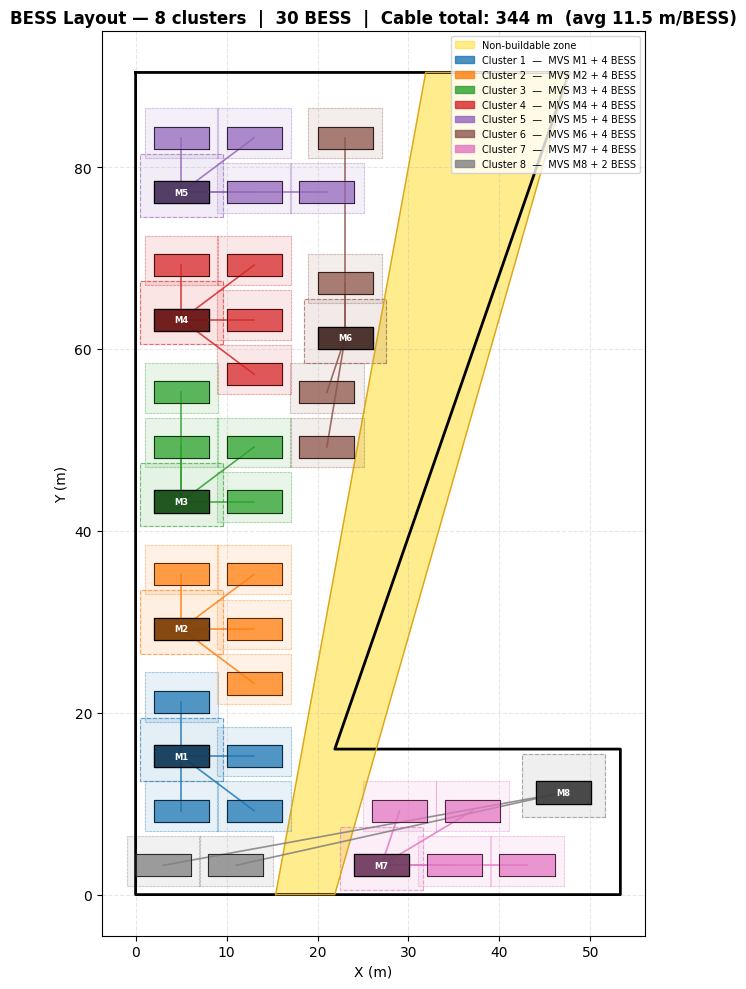

In [25]:
site, non_buildable, mvs, bess = run_optimization(CONFIG)
plot_layout(site, non_buildable, mvs, bess, CONFIG)
